<a href="https://colab.research.google.com/github/ChristosDiak/Ergasia./blob/main/Ergasia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1ο βήμα: εισαγωγή βιβλιοθηκών
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#2ο βήμα: εισαγωγή και εκτύπωση δεδομένων

#εισαγωγή του συνόλου δεδομένων
url = "https://raw.githubusercontent.com/jimtak80/AI_EKPA/main/Data/DarkNet.csv"
df = pd.read_csv(url)

#εκτύπωση των πρώτων εγγραφών και έλενχο σχήματος συνόλου δεδομένων
print("Διαστάσεις Dataset (Εγγραφές, Στήλες):", df.shape)
print("\n Πρώτες 5 εγγραφές:")
print(df.head())

Διαστάσεις Dataset (Εγγραφές, Στήλες): (68580, 83)

 Πρώτες 5 εγγραφές:
          Src_IP  Src_Port          Dst_IP  Dst_Port  Protocol  Flow_Duration  \
0  10.152.152.11     57158   216.58.220.99       443         6            229   
1  10.152.152.11     57159   216.58.220.99       443         6            407   
2  10.152.152.11     57160   216.58.220.99       443         6            431   
3  10.152.152.11     49134  74.125.136.120       443         6            359   
4  10.152.152.11     34697  173.194.65.127     19305         6       10778451   

   Total_Fwd_Packet  Total_Bwd_packets  Total_Length_of_Fwd_Packet  \
0                 1                  1                           0   
1                 1                  1                           0   
2                 1                  1                           0   
3                 1                  1                           0   
4               591                400                       64530   

   Total_Length_of_B

/tmp/ipykernel_1021/1314430435.py:5: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [3]:
#3ο βήμα: προεπεξεργασία και καθαρισμος δεδομένων

# αφαίρεση ταυτοποιητικών στηλών (IPs, Ports, Timestamps, IDs)
# που προκαλούν σφάλματα ή overfitting στους αλγορίθμους
cols_to_drop = ['Flow ID', 'Src IP', 'Source IP', 'Dst IP', 'Destination IP', 'Timestamp']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

#Αντικατάσταση των τιμών άπειρου με ΝaN
df = df.replace([np.inf, -np.inf], np.nan)

#Διαγραφή όλων των εγγραφών που περιέχουν ελλείπουσες τιμές (NaN)
df = df.dropna()


In [4]:
#Διαχωρισμός σε ανεξάρτητες μεταβλητές (X) και ετικέτα-στόχο y (Label)
X = df.iloc[:, :-1]

In [5]:
#Η τελευταία στήλη περιέχει την κατηγορία (π.χ. Tor / Non-Tor)
y = df.iloc[:, -1]

In [6]:
# Κρατάμε ΑΠΟΚΛΕΙΣΤΙΚΑ τις αριθμητικές στήλες
X = X.select_dtypes(include=[np.number])

In [7]:
#4o βήμα: διαχωρισμός συνόλου δεδομένων (train / test)

#Διαχωρισμός 80% για εκπαίδευση (Train) και 20% για αξιολόγηση (Test) και Χρήση stratify=y για διατήρηση της αναλογίας των κλάσεων και στα δύο σύνολα
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
#5ο βήμα: εκπαίδευση μοντέλου μηχανικής μάθησης

#χρήση του αλγορίθμου Random Forest Classifier και με χρήση λιγότερων
model = RandomForestClassifier(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=50, n_jobs=-1,
                       random_state=42)


 Αναφορά ταξινόμησης
                 precision    recall  f1-score   support

AUDIO-STREAMING       1.00      0.78      0.87       294
Audio-Streaming       0.86      0.69      0.76      1211
       Browsing       0.80      0.85      0.83      1038
           Chat       0.73      0.83      0.78      2295
          Email       0.73      0.55      0.63      1229
  File-Transfer       0.87      0.88      0.88      2218
  File-transfer       1.00      0.47      0.64        17
            P2P       0.98      0.99      0.99      2742
           VOIP       0.59      0.52      0.55       713
Video-Streaming       0.76      0.87      0.81      1894
Video-streaming       0.72      0.23      0.35        56

       accuracy                           0.82     13707
      macro avg       0.82      0.70      0.74     13707
   weighted avg       0.82      0.82      0.82     13707



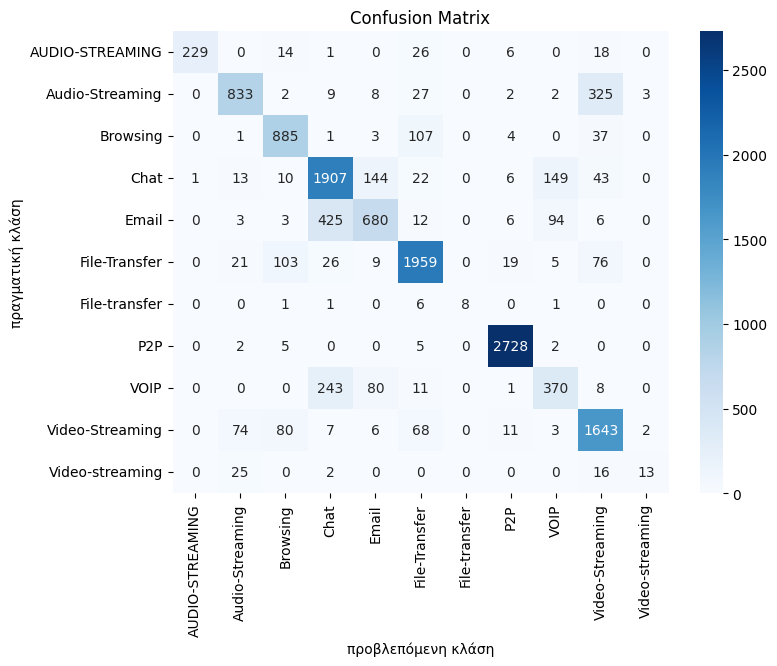

In [9]:
#6ο βήμα: αξιολόγηση και αποτελέσματα

#πρόβλεψη των κλάσεων στο σύνολο δοκιμής
y_pred=model.predict(X_test)

#εκτύπωση αναφοράς ταξινόμησης
print("\n Αναφορά ταξινόμησης")
print(classification_report(y_test, y_pred))

#δημιουργία και οπτικοποίηση πίνακα σύνχυσης
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('προβλεπόμενη κλάση')
plt.ylabel('πραγματική κλάση')
plt.show()